In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [7]:
df = pd.read_csv("Sample - Superstore.csv", encoding='latin1')

In [8]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [10]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   str           
 2   Order Date     9994 non-null   datetime64[us]
 3   Ship Date      9994 non-null   datetime64[us]
 4   Ship Mode      9994 non-null   str           
 5   Customer ID    9994 non-null   str           
 6   Customer Name  9994 non-null   str           
 7   Segment        9994 non-null   str           
 8   Country        9994 non-null   str           
 9   City           9994 non-null   str           
 10  State          9994 non-null   str           
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   str           
 13  Product ID     9994 non-null   str           
 14  Category       9994 non-null   str           
 15  Sub-Category   9994 non-null   s

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df['Month'] = df['Order Date'].dt.month

df['Year'] = df['Order Date'].dt.year

In [14]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Month,Year
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,11,2016
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,11,2016
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,6,2016
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,10,2015
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,10,2015


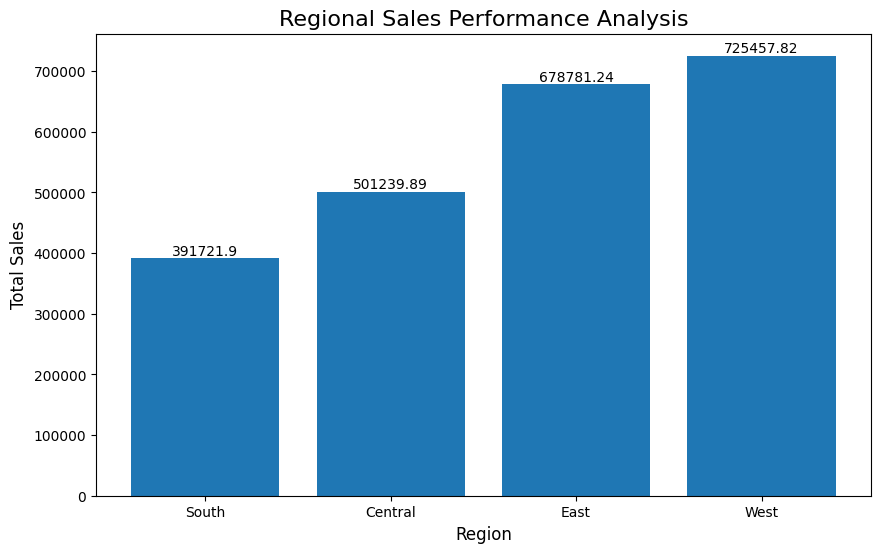

In [15]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values()

plt.figure(figsize=(10,6))

bars = plt.bar(region_sales.index, region_sales.values)

plt.title("Regional Sales Performance Analysis", fontsize=16)
plt.xlabel("Region", fontsize=12)
plt.ylabel("Total Sales", fontsize=12)

plt.xticks(rotation=0)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval,
             round(yval,2),
             ha='center',
             va='bottom')

plt.show()

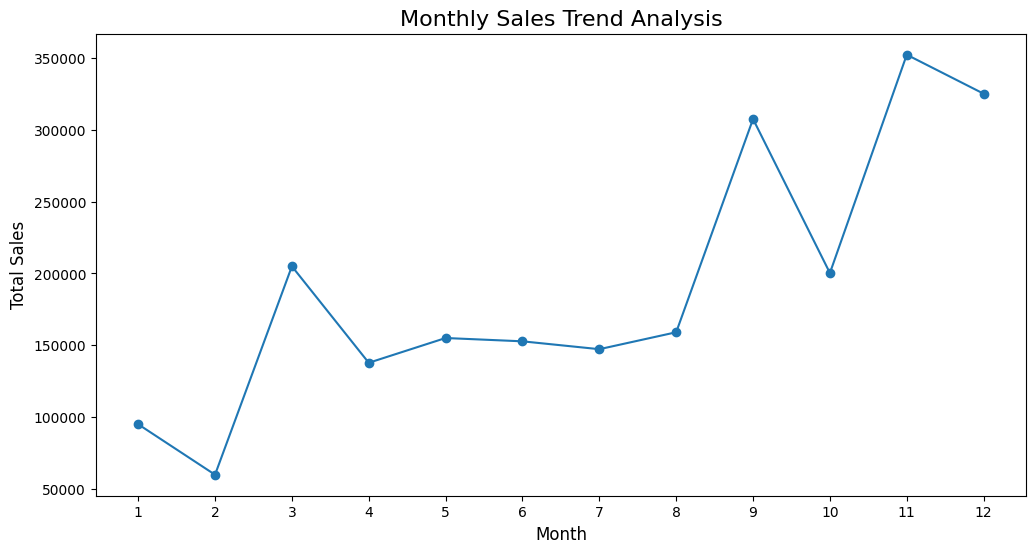

In [16]:
monthly_sales = df.groupby('Month')['Sales'].sum()

plt.figure(figsize=(12,6))

plt.plot(monthly_sales.index,
         monthly_sales.values,
         marker='o')

plt.title("Monthly Sales Trend Analysis", fontsize=16)

plt.xlabel("Month", fontsize=12)
plt.ylabel("Total Sales", fontsize=12)

plt.xticks(monthly_sales.index)

plt.show()

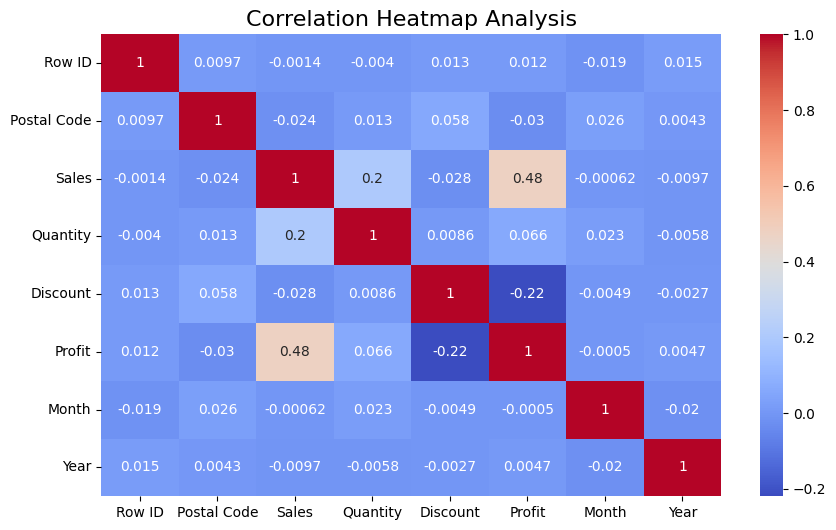

In [17]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))

sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap Analysis",
          fontsize=16)

plt.show()

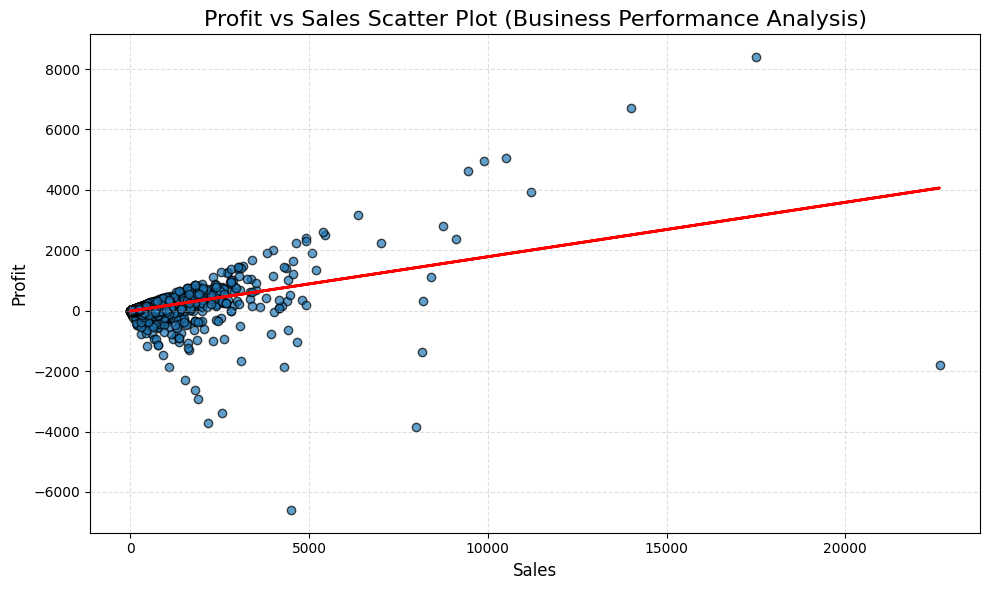

In [19]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 6))

plt.scatter(df['Sales'], df['Profit'], alpha=0.7, edgecolor='black')

plt.title("Profit vs Sales Scatter Plot (Business Performance Analysis)", fontsize=16)
plt.xlabel("Sales", fontsize=12)
plt.ylabel("Profit", fontsize=12)

plt.grid(True, linestyle='--', alpha=0.4)

z = np.polyfit(df['Sales'], df['Profit'], 1)
p = np.poly1d(z)
plt.plot(df['Sales'], p(df['Sales']), color='red', linewidth=2)

plt.tight_layout()
plt.show()

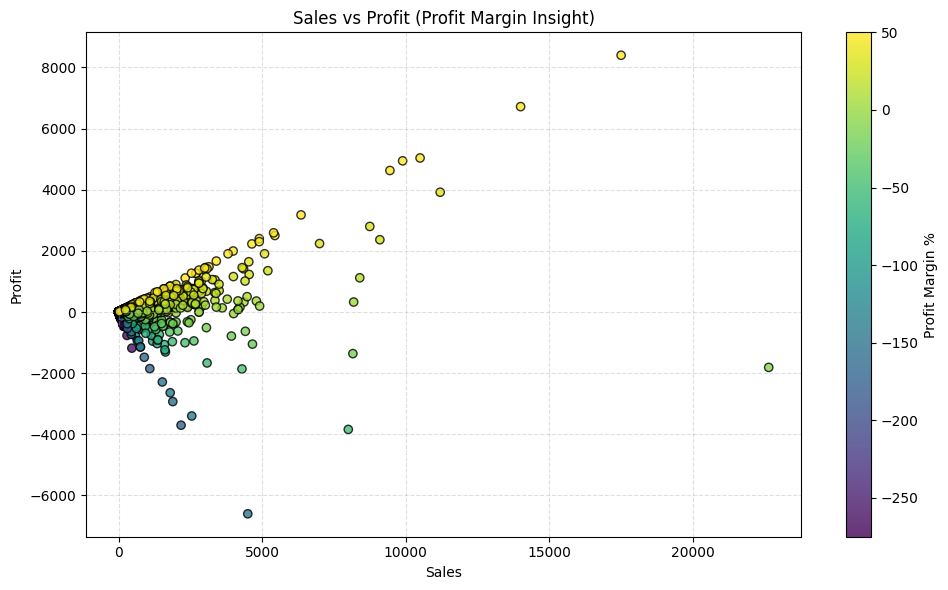

In [20]:
import matplotlib.pyplot as plt

df['Profit_Margin'] = (df['Profit'] / df['Sales']) * 100

plt.figure(figsize=(10,6))

plt.scatter(df['Sales'], df['Profit'], 
            c=df['Profit_Margin'], cmap='viridis', 
            alpha=0.8, edgecolor='black')

plt.colorbar(label='Profit Margin %')

plt.title("Sales vs Profit (Profit Margin Insight)")
plt.xlabel("Sales")
plt.ylabel("Profit")

plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

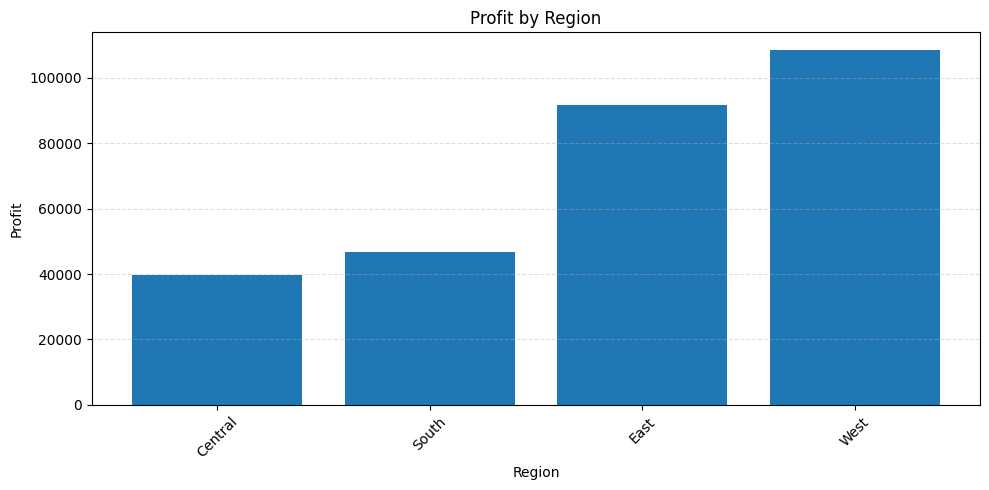

In [21]:
region_profit = df.groupby('Region')['Profit'].sum().sort_values()

plt.figure(figsize=(10,5))
plt.bar(region_profit.index, region_profit.values)

plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [22]:
df[['Sales','Profit']].corr()

,Sales,Profit
Sales,1.000000,0.479064
Profit,0.479064,1.000000


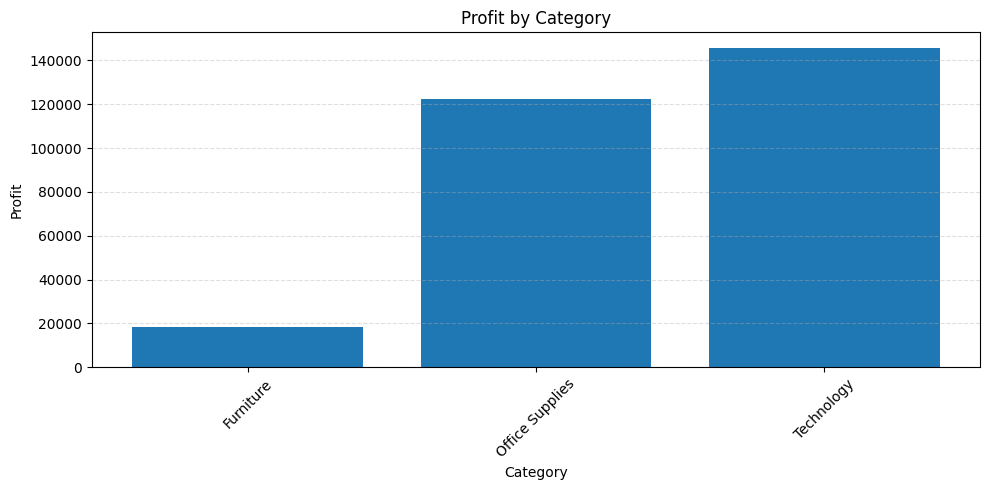

In [23]:
category_profit = df.groupby('Category')['Profit'].sum().sort_values()

plt.figure(figsize=(10,5))
plt.bar(category_profit.index, category_profit.values)

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv("Sample - Superstore.csv", encoding='latin1')

In [7]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [8]:
df['Month'] = df['Order Date'].dt.month
df['Year'] = df['Order Date'].dt.year

In [9]:
df['Sales_Category'] = df['Sales'].apply(
    lambda x: 'High' if x > 1000 else 'Medium' if x > 500 else 'Low'
)

In [10]:
df['Profit_Margin'] = (df['Profit'] / df['Sales']) * 100

In [11]:
df['Month'] = df['Order Date'].dt.month

df['Year'] = df['Order Date'].dt.year

df['Sales_Category'] = df['Sales'].apply(
    lambda x: 'High' if x > 1000 else 'Medium' if x > 500 else 'Low'
)

df['Profit_Margin'] = (df['Profit'] / df['Sales']) * 100

In [12]:
df[['Sales', 'Profit', 'Profit_Margin']].head()

,Sales,Profit,Profit_Margin
0,261.9600,41.9136,16.00
1,731.9400,219.5820,30.00
2,14.6200,6.8714,47.00
3,957.5775,-383.0310,-40.00
4,22.3680,2.5164,11.25


In [14]:
df.shape

(9994, 25)

In [15]:
df.to_csv("cleaned_superstore.csv",
          index=False,
          encoding='utf-8')

In [16]:
import os
print(os.getcwd())

c:\Users\admin\OneDrive\Documents\DA\data
